In [1]:
import sqlite3
import sys
import os
import json
import re   

In [9]:
conn = sqlite3.connect('sales_database.db')

In [21]:
import sqlite3

# 1. Connect to the database
conn = sqlite3.connect('sales_data.db')

# 2. Create a cursor object
cursor = conn.cursor()

# 3. Execute SQL to create a table (corrected version)
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        Order_id INTEGER PRIMARY KEY AUTOINCREMENT,
        Order_date DATE NOT NULL,
        Customer_name TEXT,
        Ship_date DATE,
        Price REAL,
        Quantity INTEGER,
        Total REAL
    )
''')

# 4. Commit the changes
conn.commit()

# 5. Close the connection
#conn.close()

In [ ]:

# Syntax to remove a database 
conn.close()
os.remove('sales_database.db')

In [13]:
from datetime import date

## Step 1

In [5]:
# Corrected sales data with proper formatting and commas

sales_tab = [
        (1001,	'01-01-2024',	'John Smith',	'03-01-2024',	49.99,	2,	9.998,	109.978),
        (1002,	'01-01-2024',	'Jane Doe',	'04-01-2024',	29.99,	1,	2.999,	32.989),
        (1003,	'02-01-2024',	'Michael Johnson',	'07-01-2024',	99.99,	3,	29.997,	329.967),
        (1004,	'02-01-2024',	'Emily Brown',	'03-01-2024',	19.99,	4,	7.996,	87.956),
        (1005,	'03-01-2024',	'David Wilson',	'08-01-2024',	149.99,	1,	14.999,	164.989),
        (1006,	'03-01-2024',	'Lisa Taylor',	'06-01-2024',	79.99,	2,	15.998,	175.978),
        (1007,	'04-01-2024',	'Daniel Martinez',	'06-01-2024',	39.99,	3,	11.997,	131.967),
        (1008,	'04-01-2024',	'Sarah Anderson',	'09-01-2024',	69.99,	2,	13.998,	153.978),
        (1009,	'05-01-2024',	'Christopher Thomas',	'06-01-2024',	89.99,	1,	8.999,	98.989),
        (1010,	'05-01-2024',	'Kimberly Garcia',	'08-01-2024',	199.99,	1,	19.999,	219.989),
        (1011,	'06-01-2024',	'William Hernandez',	'07-01-2024',	29.99,	5,	14.995,	164.945),
        (1012,	'06-01-2024',	'Melissa Lopez',	'08-01-2024',	79.99,	2,	15.998,	175.978),
        (1013,	'07-01-2024',	'Richard Perez',	'09-01-2024',	49.99,	3,	14.997,	164.967),
        (1014, '07-01-2024', 'Jessica Gonzalez', '12-01-2024', 129.99, 1, 12.999, 142.989),
        (1015, '08-01-2024', 'Matthew Wilson', '13-01-2024', 19.99, 4, 7.996, 87.956),
        (1016, '08-01-2024', 'Amanda Martinez', '12-01-2024', 149.99, 1, 14.999, 164.989),
        (1017, '09-01-2024', 'James Johnson', '14-01-2024', 69.99, 2, 13.998, 153.978),
        (1018, '09-01-2024', 'Laura Brown', '12-01-2024', 39.99, 3, 11.997, 131.967),
        (1019, '10-01-2024', 'Daniel Smith', '11-01-2024', 199.99, 1, 19.999, 219.989),
        (1020, '10-01-2024', 'Jennifer Davis', '14-01-2024', 29.99, 5, 14.995, 164.945),
        (1021,	'11-01-2024',	'Michael Garcia',	'14-01-2024',	79.99,	2,	15.998,	175.978),
        (1022,	'11-01-2024',	'Amy Hernandez',	'15-01-2024',	49.99,	3,	14.997,	164.967),
        (1023,	'12-01-2024',	'Christopher Rodriguez',	'17-01-2024',	129.99,	1,	12.999,	142.989),
        (1024,	'12-01-2024',	'Jessica Martinez',	'17-01-2024',	19.99,	4,	7.996,	87.956),
        (1025,	'13-01-2024',	'David Wilson',	'17-01-2024',	149.99,	1,	14.999,	164.989),
        (1026,	'13-01-2024',	'Sarah Smith',	'14-01-2024',	69.99,	2,	13.998,	153.978),
        (1027,	'14-01-2024',	'Matthew Johnson',	'18-01-2024',	39.99,	3,	11.997,	131.967),
        (1028,	'14-01-2024',	'Emily Davis',	'19-01-2024',	199.99,	1,	19.999,	219.989),
        (1029,	'15-01-2024',	'Daniel Wilson',	'19-01-2024',	29.99,	5,	14.995,	164.945),
        (1030,	'15-01-2024',	'Jennifer Martinez',	'19-01-2024',	79.99,	2,	15.998,	175.978),
        (1031,	'16-01-2024',	'Michael Smith',	'19-01-2024',	49.99,	3,	14.997,	164.967),
        (1032,	'16-01-2024',	'Jessica Johnson',	'17-01-2024',	129.99,	1,	12.999,	142.989),
        (1033,	'17-01-2024',	'David Brown',	'19-01-2024',	19.99,	4,	7.996,	87.956),
        (1034,	'17-01-2024',	'Sarah Garcia',	'19-01-2024',	149.99,	1,	14.999,	164.989),
        (1035,	'18-01-2024',	'Matthew Hernandez',	'23-01-2024',	69.99,	2,	13.998,	153.978),
        (1036,	'18-01-2024',	'Emily Rodriguez',	'19-01-2024',	39.99,	3,	11.997,	131.967),
        (1037,	'19-01-2024',	'Daniel Davis',	'20-01-2024',	199.99,	1,	19.999,	219.989),
        (1038,	'19-01-2024',	'Jennifer Smith',	'22-01-2024',	29.99,	5	,14.995,	164.945),
        (1039,	'20-01-2024',	'Michael Johnson',	'24-01-2024',	79.99,	2,	15.998,	175.978),
        (1040,	'20-01-2024',	'Jessica Martinez',	'21-01-2024',	49.99,	3,	14.997,	164.967),
        (1041,	'21-01-2024',	'David Wilson',	'26-01-2024',	129.99,	1,	12.999,	142.989),
        (1042,	'21-01-2024',	'Sarah Johnson',	'23-01-2024',	19.99,	4,	7.996,	87.956),
        (1043,	'22-01-2024',	'Matthew Garcia',	'25-01-2024',	149.99,	1,	14.999,	164.989),
        (1044,	'22-01-2024',	'Emily Brown',	'25-01-2024',	69.99,	2,	13.998,	153.978),
        (1045,	'23-01-2024',	'Daniel Hernandez',	'27-01-2024',	39.99,	3,	11.997,	131.967),
        (1046,	'23-01-2024',	'Jennifer Davis',	'26-01-2024',	199.99,	1,	19.999,	219.989),
        (1047,	'24-01-2024',	'Michael Martinez',	'25-01-2024',	29.99,	5,	14.995,	164.945),
        (1048,	'24-01-2024',	'Jessica Wilson',	'26-01-2024',	79.99,	2,	15.998,	175.978),
        (1049,	'25-01-2024',	'David Rodriguez',	'30-01-2024',	49.99,	3,	14.997,	164.967),
        (1050,	'25-01-2024',	'Sarah Gonzalez',	'27-01-2024',	129.99,	1,	12.999,	142.989),
        (1051,	'26-01-2024',	'Matthew Smith',	'29-01-2024',	19.99,	4,	7.996,	87.956),
        (1052,	'26-01-2024',	'Emily Johnson',	'28-01-2024',	149.99,	1,	14.999,	164.989),
        (1053,	'27-01-2024',	'Daniel Brown',	'31-01-2024',	69.99,	2,	13.998,	153.978),
        (1054,	'27-01-2024',	'Jennifer Hernandez',	'31-01-2024',	39.99,	3,	11.997,	131.967),
        (1055,	'28-01-2024',	'Michael Davis',	'29-01-2024',	199.99,	1,	19.999,	219.989),
        (1056,	'28-01-2024',	'Jessica Smith',	'29-01-2024',	29.99,	5,	14.995,	164.945),
        (1057,	'29-01-2024',	'David Martinez',	'30-01-2024',	79.99,	2,	15.998,	175.978),
        (1058,	'29-01-2024',	'Sarah Johnson',	'31-01-2024',	49.99,	3,	14.997,	164.967),
        (1059,	'30-01-2024',	'Matthew Garcia',	'31-01-2024',	129.99,	1,	12.999,	142.989),
        (1060,	'30-01-2024',	'Emily Brown',	'01-02-2024',	19.99,	4,	7.996,	87.956),
        (1061,	'31-01-2024',	'Daniel Hernandez',	'02-02-2024',	149.99,	1,	14.999,	164.989),
        (1062,	'31-01-2024',	'Jennifer Davis',	'04-02-2024',	69.99,	2,	13.998,	153.978),
        (1063,	'01-02-2024',	'Michael Martinez',	'02-02-2024',	39.99,	3,	11.997,	131.967),
        (1064,	'01-02-2024',	'Jessica Wilson',	'05-02-2024',	199.99,	1,	19.999,	219.989),
        (1065,	'01-02-2024',	'David Rodriguez',	'03-02-2024',	29.99,	5,	14.995,	164.945),
        (1066,	'02-02-2024',	'Sarah Gonzalez',	'06-02-2024',	79.99,	2,	15.998,	175.978),
        (1067,	'03-02-2024',	'Matthew Smith',	'06-02-2024',	49.99,	3,	14.997,	164.967),
        (1068,	'04-02-2024',	'Emily Johnson',	'05-02-2024',	129.99,	1,	12.999,	142.989),
        (1069,	'04-02-2024',	'Daniel Brown',	'08-02-2024',	19.99,	4,	7.996,	87.956),
        (1070,	'04-02-2024',	'Jennifer Hernandez',	'07-02-2024',	149.99,	1,	14.999,	164.989)

]

## Step 2

In [13]:
import sqlite3

try:
    # Create connection and cursor
    conn = sqlite3.connect('sales_database.db')
    cursor = conn.cursor()

    # Create the sales table with all required columns
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS sales (
            Order_id INTEGER,
            Order_date TEXT NOT NULL,
            Customer_name TEXT NOT NULL,
            Ship_date TEXT,
            Retail_price REAL NOT NULL,
            Order_quantity INTEGER NOT NULL,
            Tax REAL NOT NULL,
            Total REAL NOT NULL
        )
    ''')

    # Insert all records
    cursor.executemany('''
        INSERT INTO sales (
            Order_id, Order_date, Customer_name, Ship_date, 
            Retail_price, Order_quantity, Tax, Total
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
    ''', sales_tab)

    conn.commit()
    print("Data inserted successfully!")

except sqlite3.Error as e:
    print(f"Database error: {e}")
    
finally:
    if conn:
        conn.close()

Database error: database is locked


## Step 2 alternative , try this if step 2 not runs or throws error like "Database locked"

In [14]:
import sqlite3

try:
    # Connect with timeout and use context manager
    with sqlite3.connect('new_sales_database.db', timeout=20) as conn:
        cursor = conn.cursor()
        
        # Create the sales table
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS sales (
                Order_id INTEGER,
                Order_date TEXT NOT NULL,
                Customer_name TEXT NOT NULL,
                Ship_date TEXT,
                Retail_price REAL NOT NULL,
                Order_quantity INTEGER NOT NULL,
                Tax REAL NOT NULL,
                Total REAL NOT NULL
            )
        ''')
        
        # Insert all records
        cursor.executemany('''
            INSERT INTO sales (
                Order_id, Order_date, Customer_name, Ship_date, 
                Retail_price, Order_quantity, Tax, Total
            ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        ''', sales_tab)
        
        print("Data inserted successfully!")

except sqlite3.Error as e:
    print(f"Database error: {e}")

Data inserted successfully!


## Step 3

Connected to database successfully!

=== TOTAL SALES SUMMARY ===
Total Quantity Sold: 168
Total Revenue: $10,855.15
Total Tax Collected: $986.83

=== SALES BY CUSTOMER ===
     Customer_name  quantity  revenue
    Jennifer Davis         8  538.912
   Michael Johnson         5  505.945
      David Wilson         3  472.967
    Jessica Wilson         3  395.967
   David Rodriguez         8  329.912
       Emily Brown        10  329.890
    Sarah Gonzalez         3  318.967
    Matthew Garcia         2  307.978
     Emily Johnson         2  307.978
Jennifer Hernandez         4  296.956


<Figure size 1000x600 with 0 Axes>

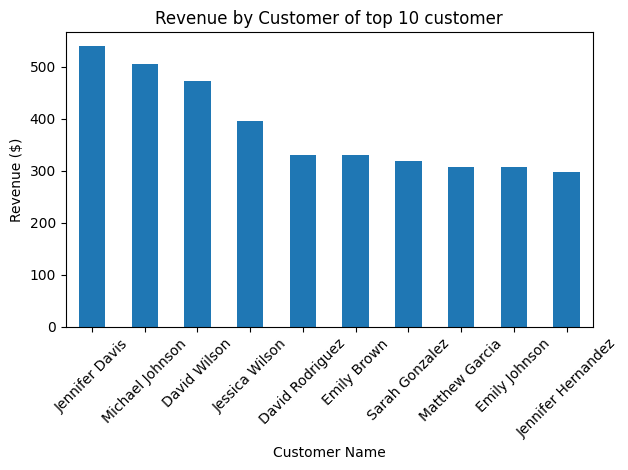

In [17]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

def sales_analysis():
    try:
        # Connect to the database
        with sqlite3.connect('new_sales_database.db') as conn:
            print("Connected to database successfully!")
            
            # Query 1: Total sales summary
            total_sales_query = """
                SELECT 
                    SUM(Order_quantity) AS total_quantity_sold,
                    SUM(Total) AS total_revenue,
                    SUM(Tax) AS total_tax
                FROM sales
            """
            
            # Query 2: Sales by customer
            customer_sales_query = """
                SELECT 
                    Customer_name,
                    SUM(Order_quantity) AS quantity,
                    SUM(Total) AS revenue
                FROM sales
                GROUP BY Customer_name
                ORDER BY revenue DESC
                limit 10
            """
            
            # Execute queries and load into pandas
            total_df = pd.read_sql_query(total_sales_query, conn)
            customer_df = pd.read_sql_query(customer_sales_query, conn)
            
            # Display results
            print("\n=== TOTAL SALES SUMMARY ===")
            print(f"Total Quantity Sold: {total_df['total_quantity_sold'][0]}")
            print(f"Total Revenue: ${total_df['total_revenue'][0]:,.2f}")
            print(f"Total Tax Collected: ${total_df['total_tax'][0]:,.2f}")
            
            print("\n=== SALES BY CUSTOMER ===")
            print(customer_df.to_string(index=False))
            
            # Create bar chart
            plt.figure(figsize=(10, 6))
            customer_df.plot(kind='bar', x='Customer_name', y='revenue', 
                           title='Revenue by Customer of top 10 customer', legend=False)
            plt.ylabel('Revenue ($)')
            plt.xlabel('Customer Name')
            plt.xticks(rotation=45)
            plt.tight_layout()
            
            # Save and show chart
            plt.savefig('customer_revenue.png')
            plt.show()
            
    except sqlite3.Error as e:
        print(f"Database error: {e}")
    except Exception as e:
        print(f"Error: {e}")

# Run the analysis
sales_analysis()

## Step 4

Connected to database successfully!


C:\Users\coolc\AppData\Local\Temp\ipykernel_7036\4189116025.py:36: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


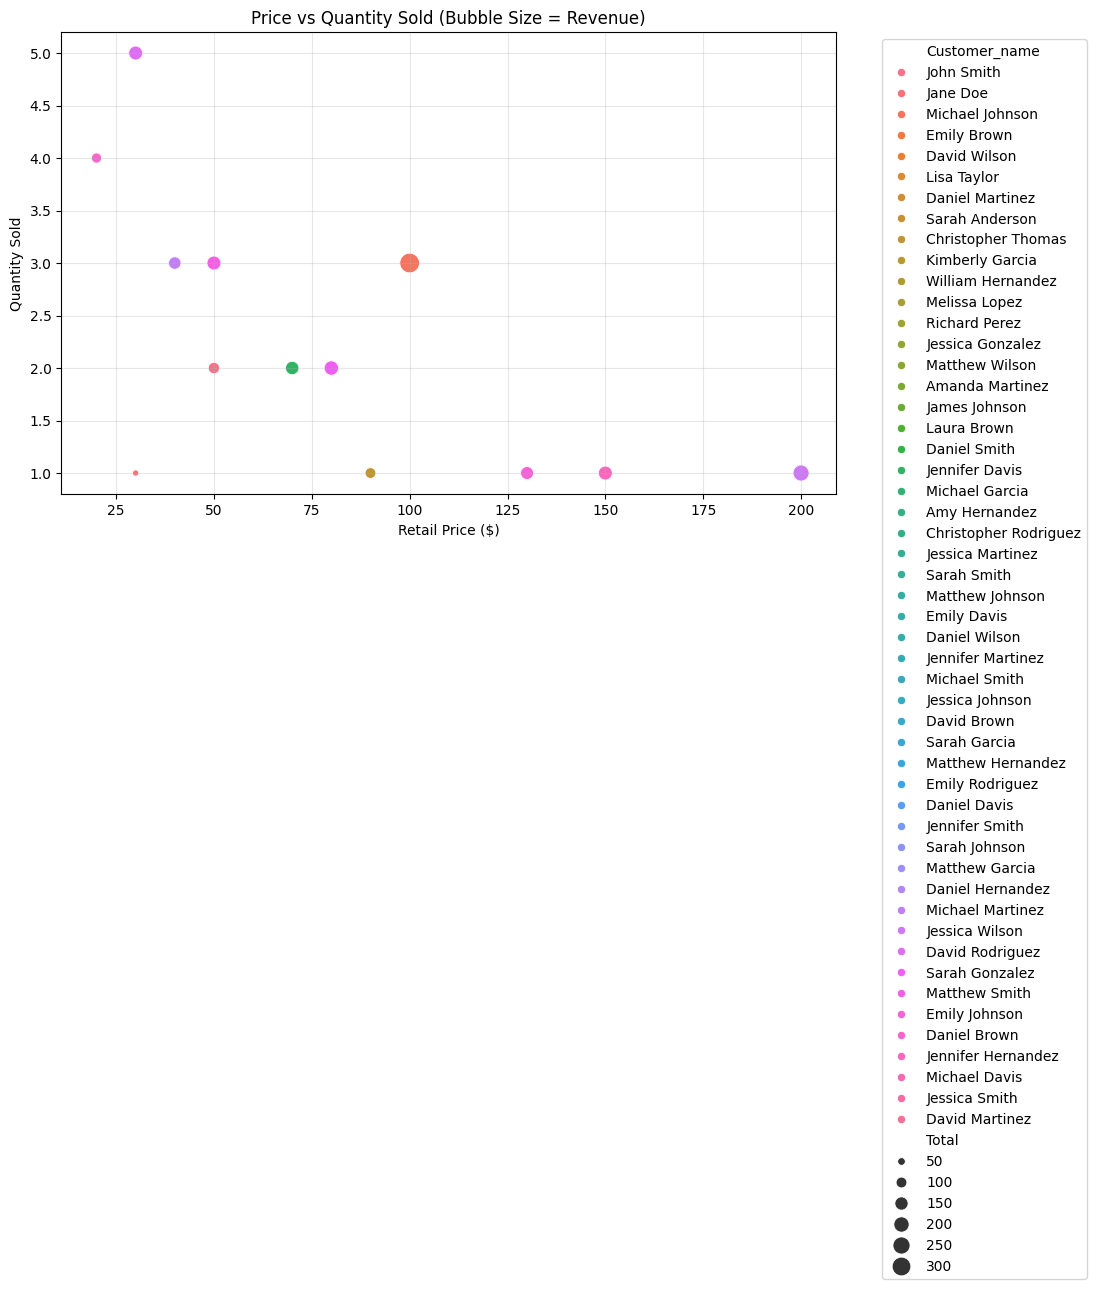

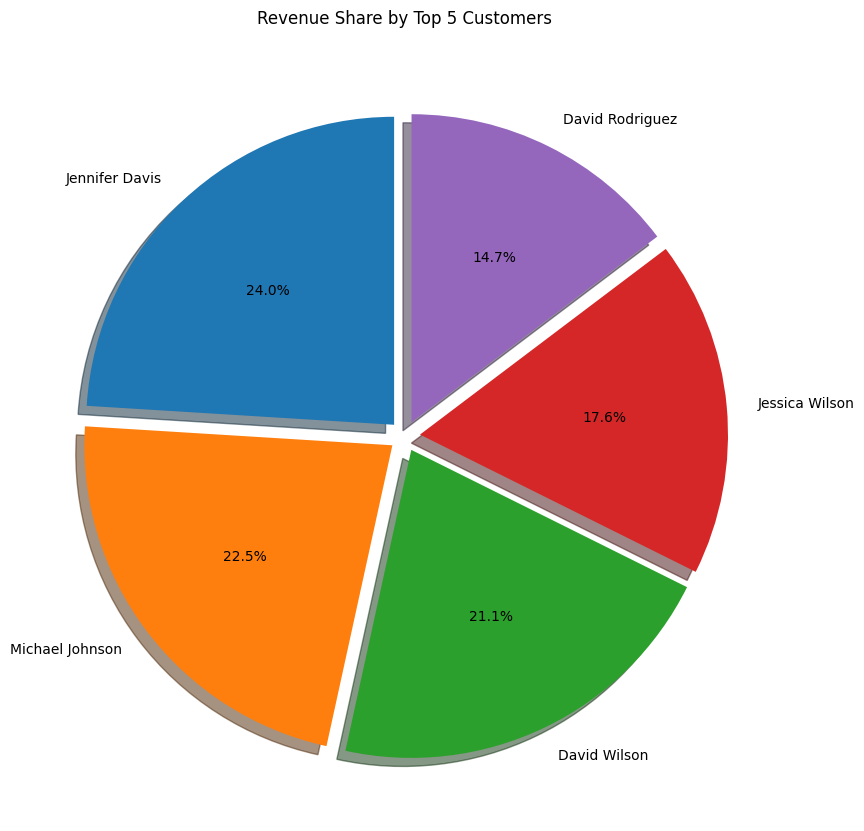

In [20]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter

def advanced_sales_visualizations():
    try:
        # Connect to the database
        with sqlite3.connect('new_sales_database.db') as conn:
            print("Connected to database successfully!")
            
            # Convert Order_date to datetime in SQL query
            sales_df = pd.read_sql_query("""
                SELECT 
                    Order_id,
                    date(Order_date) as Order_date,
                    Customer_name,
                    Retail_price,
                    Order_quantity,
                    Tax,
                    Total
                FROM sales
            """, conn, parse_dates=['Order_date'])
            
            
            # 1. Price Elasticity Analysis
            plt.figure(figsize=(10, 6))
            sns.scatterplot(data=sales_df, x='Retail_price', y='Order_quantity', 
                          hue='Customer_name', size='Total', sizes=(20, 200))
            plt.title('Price vs Quantity Sold (Bubble Size = Revenue)')
            plt.xlabel('Retail Price ($)')
            plt.ylabel('Quantity Sold')
            plt.grid(True, alpha=0.3)
            plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.savefig('price_elasticity.png')
            plt.show()
            
            # 2. Customer Revenue Composition
            top_customers = sales_df.groupby('Customer_name')['Total'].sum().nlargest(5)
            plt.figure(figsize=(10, 10))
            plt.pie(top_customers, 
                   labels=top_customers.index, 
                   autopct='%1.1f%%',
                   startangle=90,
                   shadow=True,
                   explode=[0.05]*len(top_customers))
            plt.title('Revenue Share by Top 5 Customers', pad=20)
            plt.savefig('customer_revenue_pie.png')
            plt.show()
            
            
    except sqlite3.Error as e:
        print(f"Database error: {e}")
    except Exception as e:
        print(f"Error: {e}")

# Run the visualizations
advanced_sales_visualizations()